In [1]:
import numpy as np
import keras
from keras import layers


I0000 00:00:1780395945.533127   73403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


DATA PREPARATION

-Downloading the dataset and print the input training and testing samples which will be used in training our CNN model

In [2]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


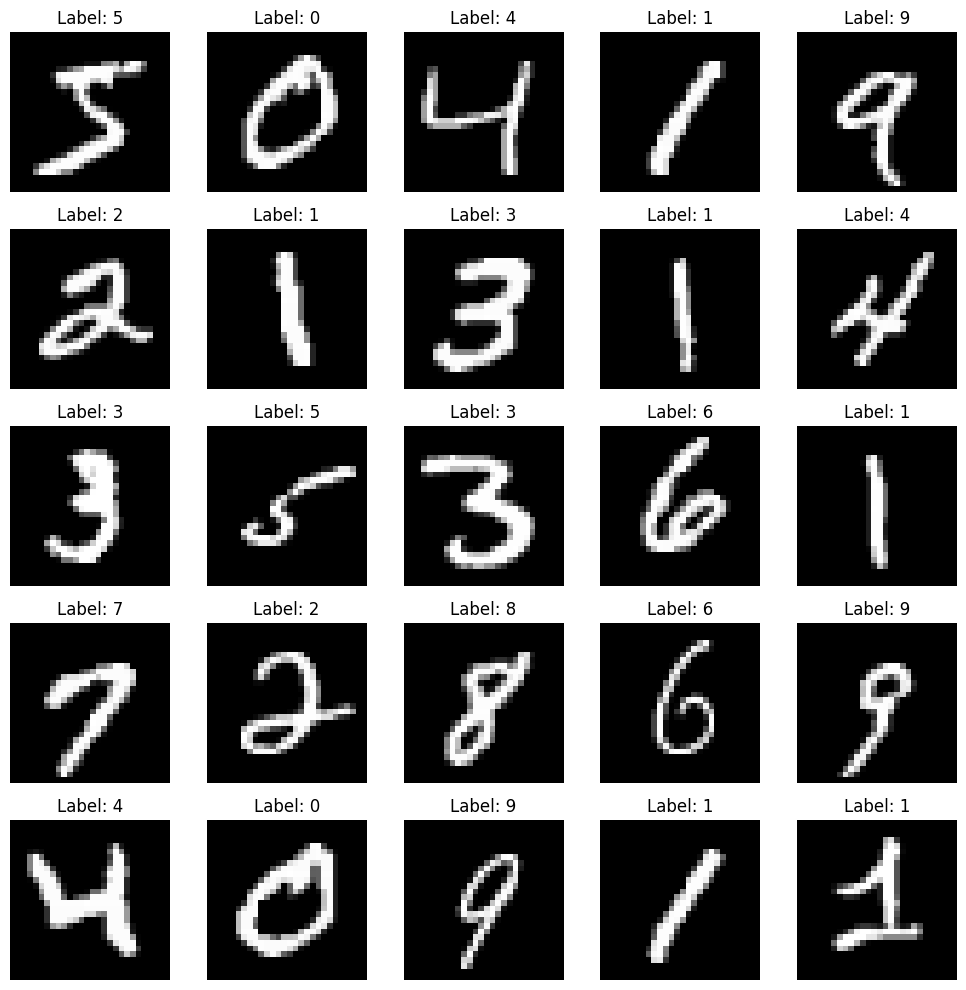

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Display a grid of sample images
def plot_sample_images(x_train, y_train, num_samples=25):
    plt.figure(figsize=(10, 10))
    
    for i in range(num_samples):
        plt.subplot(5, 5, i + 1)
        plt.imshow(x_train[i].squeeze(), cmap='gray')
        plt.title(f'Label: {np.argmax(y_train[i])}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_sample_images(x_train, y_train)

BUILDING THE MODEL AND TRAINING OUR MODEL

-Definig essential layers that are to be included in the model 

In [4]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()


W0000 00:00:1780395953.047696   73403 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8867 - loss: 0.3761 - val_accuracy: 0.9773 - val_loss: 0.0844
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9651 - loss: 0.1113 - val_accuracy: 0.9837 - val_loss: 0.0584
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9734 - loss: 0.0854 - val_accuracy: 0.9857 - val_loss: 0.0526
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9780 - loss: 0.0715 - val_accuracy: 0.9890 - val_loss: 0.0438
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9804 - loss: 0.0626 - val_accuracy: 0.9882 - val_loss: 0.0394
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9843 - loss: 0.0510 - val_accuracy: 0.9898 - val_loss: 0.0356
Epoch 8/15
292/422 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9847 - loss: 0.0517

MODEL EVALUATION

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.022916417568922043
Test accuracy: 0.991599977016449


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


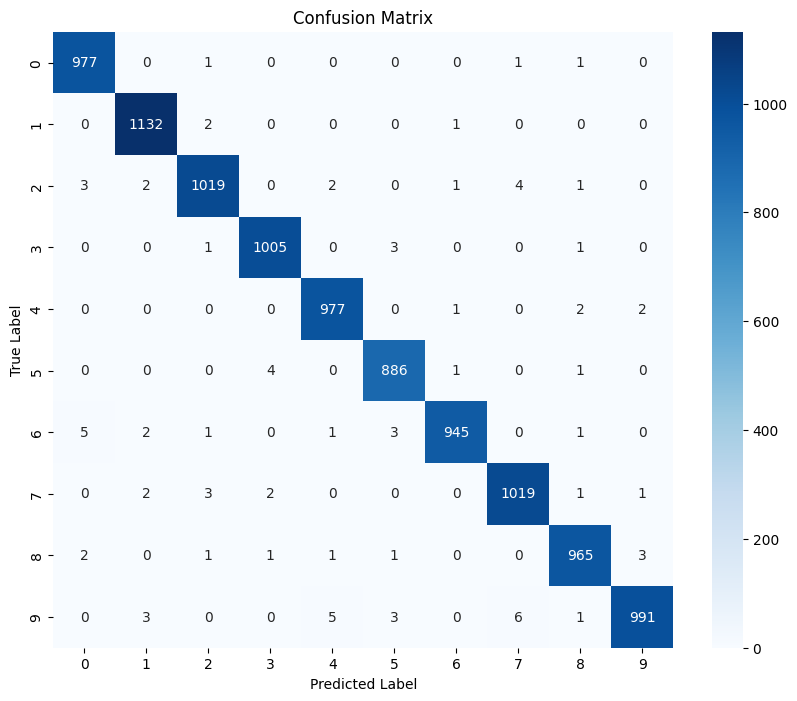

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
# Predict the labels for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# Print the classification report
class_report = classification_report(y_true_classes, y_pred_classes)
print("Classification Report:\n", class_report)


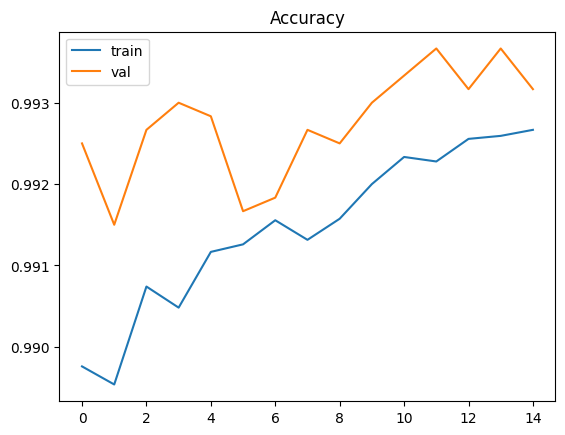

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title("Accuracy")
plt.show()

In [ ]:
pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


SAVING THE MODEL

In [ ]:
model.save("minst_model.keras")

In [ ]:
from tensorflow import keras
model = keras.models.load_model("minst_model.keras")

In [ ]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[2.71071499e-10, 1.26259051e-12, 5.83941642e-07, ...,
        9.99998391e-01, 1.31489841e-09, 9.00938772e-08],
       [3.39846862e-09, 5.21471861e-08, 9.99999940e-01, ...,
        4.29246439e-12, 2.25982681e-08, 3.06515033e-14],
       [1.27563915e-08, 9.99886811e-01, 3.58481316e-07, ...,
        3.95751667e-05, 1.55006296e-06, 1.65140221e-07],
       ...,
       [1.45984408e-16, 2.17019284e-12, 2.08867669e-14, ...,
        1.82568467e-08, 3.09458450e-08, 7.12875936e-09],
       [6.13397166e-10, 3.36499032e-16, 2.37996896e-11, ...,
        1.61913113e-13, 8.40160374e-06, 1.11706278e-09],
       [1.64004928e-06, 3.88545663e-12, 5.52000301e-07, ...,
        5.08212721e-13, 2.54643419e-05, 3.01150188e-10]], dtype=float32)